# 08 Outlier Analysis

## Objective

Objective:
Analyze numerical outliers in the cleaned churn dataset before feature engineering and modeling.

This step helps in:
- Identifying unusually large or small numerical values
- Distinguishing valid business extremes from potential data issues
- Quantifying outliers using statistical rules such as IQR and z-score checks
- Deciding whether outlier treatment is necessary before the modeling pipeline


## Imports


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS, TARGET_COLUMN
from src.data.data_loader import load_cleaned_data

sns.set_theme(style="whitegrid")


## Report Paths

Store outlier analysis outputs in dedicated figure and table folders.


In [2]:
REPORTS_DIR = project_root / "reports"
OUTLIER_FIGURES_DIR = REPORTS_DIR / "figures" / "outlier_analysis"
OUTLIER_TABLES_DIR = REPORTS_DIR / "tables" / "outlier_analysis"

for path in [OUTLIER_FIGURES_DIR, OUTLIER_TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

{
    "outlier_figures": OUTLIER_FIGURES_DIR,
    "outlier_tables": OUTLIER_TABLES_DIR,
}


{'outlier_figures': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/figures/outlier_analysis'),
 'outlier_tables': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/tables/outlier_analysis')}

## Load Clean Data

Load the cleaned dataset and separate the target, numerical, and categorical feature groups.


In [3]:
df = load_cleaned_data()

target_column = TARGET_COLUMN
numerical_columns = [column for column in NUMERICAL_COLUMNS if column in df.columns]
categorical_columns = [column for column in CATEGORICAL_COLUMNS if column in df.columns]

feature_groups = {
    "target_column": target_column,
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
    "shape": df.shape,
}

feature_groups


{'target_column': 'Churn',
 'numerical_columns': ['tenure', 'MonthlyCharges', 'TotalCharges'],
 'categorical_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 'shape': (7043, 21)}

## Numerical Summary Statistics

Start with a numerical summary to see where extreme values and skew may appear before applying any formal outlier rule.


In [4]:
outlier_summary_df = pd.DataFrame(
    {
        "count": df[numerical_columns].count(),
        "mean": df[numerical_columns].mean(),
        "median": df[numerical_columns].median(),
        "std": df[numerical_columns].std(),
        "min": df[numerical_columns].min(),
        "25%": df[numerical_columns].quantile(0.25),
        "50%": df[numerical_columns].quantile(0.50),
        "75%": df[numerical_columns].quantile(0.75),
        "max": df[numerical_columns].max(),
        "skew": df[numerical_columns].skew(),
    }
).round(2)

outlier_summary_df.to_csv(OUTLIER_TABLES_DIR / "numerical_outlier_summary.csv")
display(outlier_summary_df)


,count,mean,median,std,min,25%,50%,75%,max,skew
tenure,7043,32.37,29.00,24.56,0.00,9.00,29.00,55.00,72.00,0.24
MonthlyCharges,7043,64.76,70.35,30.09,18.25,35.50,70.35,89.85,118.75,-0.22
TotalCharges,7043,2279.73,1394.55,2266.79,0.00,398.55,1394.55,3786.60,8684.80,0.96


This summary shows whether the numerical features are naturally broad, skewed, or potentially extreme. In this dataset, a large maximum value is not automatically a problem, because long-tenure customers and high-value accounts can be valid business cases rather than errors.


## Visual Outlier Detection

Use boxplots and histograms to inspect the spread of the numerical features and see whether potential outliers look isolated or consistent with the rest of the distribution.


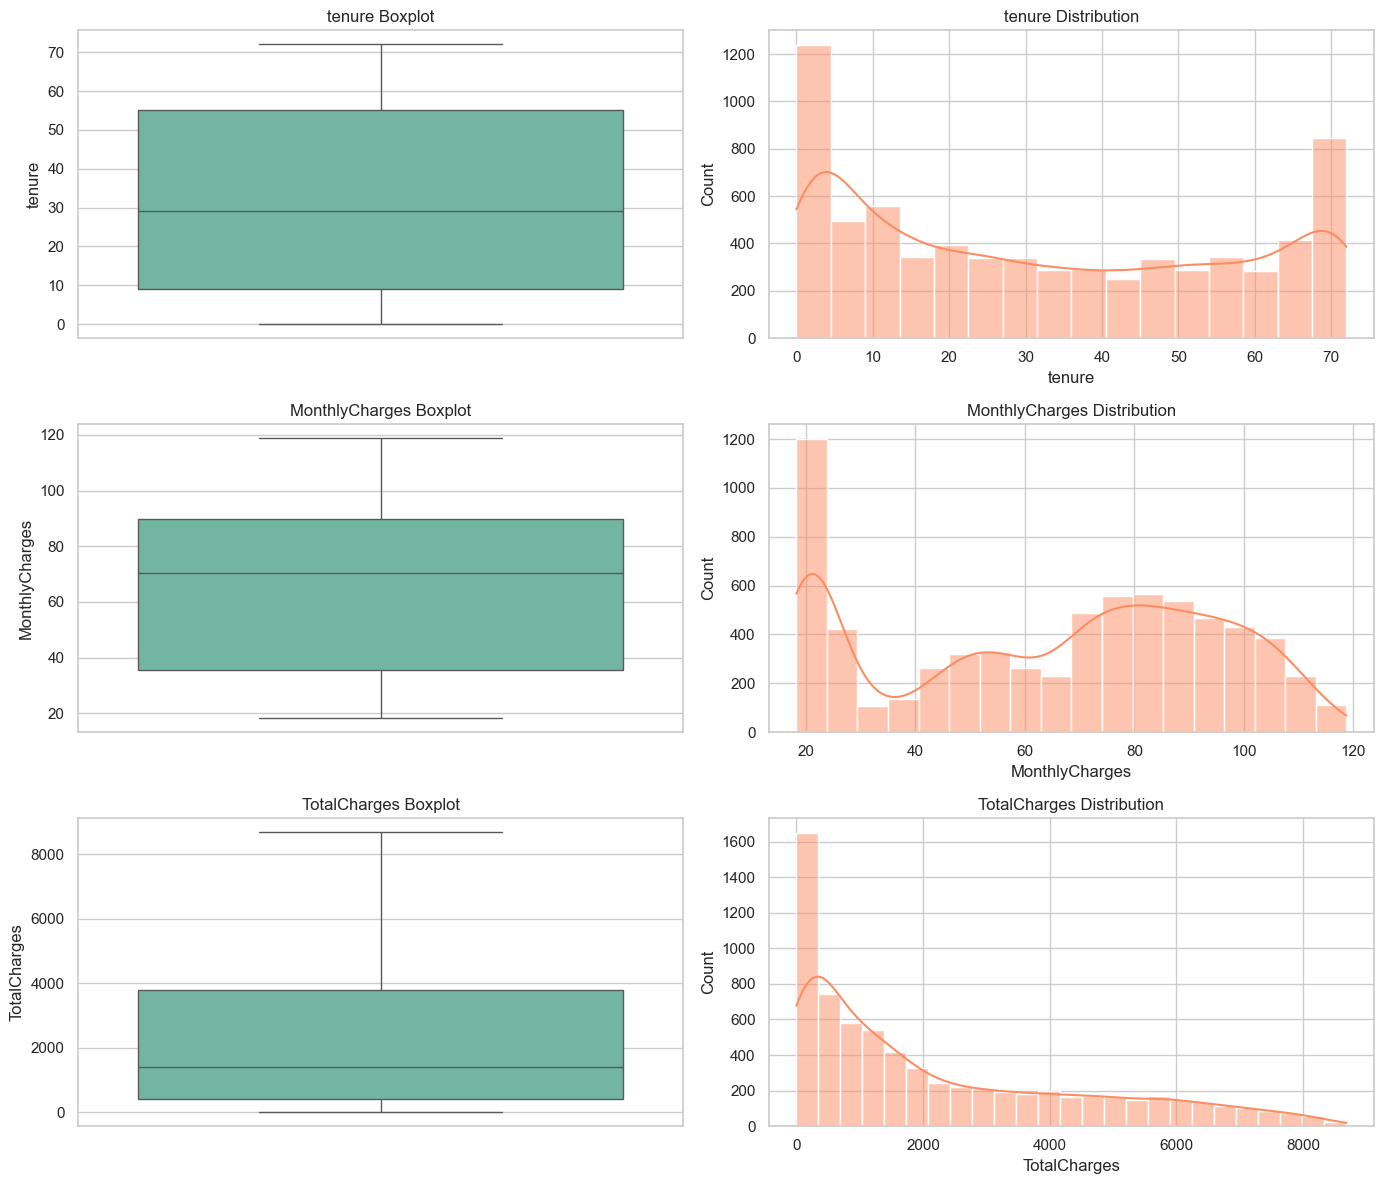

In [5]:
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(14, 4 * len(numerical_columns)))

if len(numerical_columns) == 1:
    axes = np.array([axes])

for index, column in enumerate(numerical_columns):
    box_ax, hist_ax = axes[index]

    sns.boxplot(data=df, y=column, ax=box_ax, color=sns.color_palette("Set2")[0])
    box_ax.set_title(f"{column} Boxplot")

    sns.histplot(data=df, x=column, kde=True, ax=hist_ax, color=sns.color_palette("Set2")[1])
    hist_ax.set_title(f"{column} Distribution")

plt.tight_layout()
plt.savefig(
    OUTLIER_FIGURES_DIR / "numerical_outlier_boxplots_histograms.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


The visual check helps separate suspicious data errors from valid business extremes. For this churn dataset, very high `TotalCharges` and long `tenure` are likely to be legitimate customer histories, while unusual low or zero values should be judged against business context rather than treated automatically as bad data.


## IQR-Based Outlier Detection

Use the interquartile range rule to count observations outside the typical range for each numerical feature.


In [6]:
iqr_rows = []

for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)

    iqr_rows.append(
        {
            "feature": column,
            "q1": round(float(q1), 2),
            "q3": round(float(q3), 2),
            "iqr": round(float(iqr), 2),
            "lower_bound": round(float(lower_bound), 2),
            "upper_bound": round(float(upper_bound), 2),
            "outlier_count": int(outlier_mask.sum()),
            "outlier_pct": round(float(outlier_mask.mean() * 100), 2),
        }
    )

iqr_outlier_df = pd.DataFrame(iqr_rows)
iqr_outlier_df.to_csv(OUTLIER_TABLES_DIR / "iqr_outlier_summary.csv", index=False)
display(iqr_outlier_df)


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0,0.0
2,TotalCharges,398.55,3786.60,3388.05,-4683.52,8868.67,0,0.0


The IQR table quantifies how many observations lie outside the typical range. A high outlier count does not automatically mean those rows are wrong; it may simply show that the feature has a naturally skewed or long-tailed business distribution.


## Z-Score-Based Detection

Use a z-score threshold as a secondary check. This is most informative when the distribution is closer to symmetric, so it should be interpreted carefully for skewed features.


In [7]:
z_score_rows = []

for column in numerical_columns:
    mean_value = df[column].mean()
    std_value = df[column].std(ddof=0)
    if std_value:
        z_scores = (df[column] - mean_value) / std_value
        outlier_mask = z_scores.abs() > 3
    else:
        outlier_mask = pd.Series(False, index=df.index)

    z_score_rows.append(
        {
            "feature": column,
            "zscore_outlier_count": int(outlier_mask.sum()),
            "zscore_outlier_pct": round(float(outlier_mask.mean() * 100), 2),
        }
    )

z_score_outlier_df = pd.DataFrame(z_score_rows)
z_score_outlier_df.to_csv(OUTLIER_TABLES_DIR / "zscore_outlier_summary.csv", index=False)
display(z_score_outlier_df)


,feature,zscore_outlier_count,zscore_outlier_pct
0,tenure,0,0.0
1,MonthlyCharges,0,0.0
2,TotalCharges,0,0.0


Z-score detection adds a second perspective, but skewed features can make this rule less reliable than the IQR rule. It is best used here as a supporting check rather than the main decision rule.


## Target-Aware Outlier Check

Check whether detected outliers are concentrated in one churn class. This helps determine whether the outliers are informative customer segments rather than noise.


In [8]:
target_aware_rows = []

for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)

    outlier_by_target = (
        df.assign(is_outlier=outlier_mask)
        .groupby(target_column)["is_outlier"]
        .mean()
        .mul(100)
        .round(2)
        .to_dict()
    )

    target_aware_rows.append(
        {
            "feature": column,
            "outlier_pct_churn_no": outlier_by_target.get("No", 0.0),
            "outlier_pct_churn_yes": outlier_by_target.get("Yes", 0.0),
        }
    )

target_aware_outlier_df = pd.DataFrame(target_aware_rows)
target_aware_outlier_df.to_csv(
    OUTLIER_TABLES_DIR / "target_aware_outlier_summary.csv",
    index=False,
)
display(target_aware_outlier_df)


,feature,outlier_pct_churn_no,outlier_pct_churn_yes
0,tenure,0.0,0.0
1,MonthlyCharges,0.0,0.0
2,TotalCharges,0.0,0.0


This target-aware view helps answer whether extreme values are simply unusual or actually useful for churn prediction. If outlier rates differ by churn class, the values may contain real signal and should not be removed automatically.


## Outlier Treatment Decision

- Keep values that are business-valid even if they look extreme on a boxplot.
- Prefer transformation over deletion when the issue is skew rather than data error.
- Be especially cautious with `tenure`, `MonthlyCharges`, and `TotalCharges`, because extreme values may represent valid customer history rather than noise.
- Tree-based models are usually robust to outliers, while linear models may benefit more from transformation than from row removal.


## Final Conclusion

The outlier analysis did not reveal problematic numerical outliers that require removal or capping. The extreme values observed in `tenure`, `MonthlyCharges`, and `TotalCharges` appear to reflect valid customer behavior rather than data quality issues, so no direct outlier treatment is applied at this stage. However, `TotalCharges` remains moderately right-skewed, which makes transformation a more appropriate next step than deleting rows.
